In [16]:
device = 'mps' # somehow mps is slower than cpu in eval
# device = 'cuda'

use_mps_device = True if device == 'mps' else False

# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [3]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [4]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/opt/anaconda3/envs/mase/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [5]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_best_fixpoint16_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [6]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    use_mps_device=use_mps_device,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


KeyboardInterrupt: 

To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [5]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

Traceback (most recent call last):
  File "/opt/anaconda3/envs/mase/lib/python3.11/site-packages/IPython/core/completer.py", line 3246, in _complete
    result = matcher(context)
             ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/mase/lib/python3.11/site-packages/IPython/core/completer.py", line 2139, in magic_matcher
    matches = self.magic_matches(text)
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/mase/lib/python3.11/site-packages/IPython/core/completer.py", line 2172, in magic_matches
    global_matches = self.global_matches(bare_text)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/mase/lib/python3.11/site-packages/IPython/core/completer.py", line 1114, in global_matches
    for word in lst:
RuntimeError: dictionary changed size during iteration
INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_

Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
    use_mps_device=use_mps_device,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/opt/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/training_args.py:2243: UserWarning: `use_mps_device` is deprecated and will be removed in version 5.0 of 🤗 Transformers. `mps` device will be used by default if available similar to the way `cuda` device is used.Therefore, no action from user is required. 
  warnings.warn(
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.67476


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [7]:
trainer.train()

Step,Training Loss
500,0.462700
1000,0.411800
1500,0.415700
2000,0.404900
2500,0.404600
3000,0.402800
3500,0.419000
4000,0.400400
4500,0.380700
5000,0.386600


TrainOutput(global_step=15625, training_loss=0.39059906811523437, metrics={'train_runtime': 1745.6737, 'train_samples_per_second': 71.606, 'train_steps_per_second': 8.951, 'total_flos': 0.0, 'train_loss': 0.39059906811523437, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [8]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.83496


## Task 2

In [8]:
methods = ["random", "l1-norm"]
sparsities = [0.1, 0.3, 0.5, 0.7, 0.9]
pruning_configs = []

for method in methods:
    for sparsity in sparsities:
        config = {
            "weight": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
            "activation": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
        }
        pruning_configs.append(config)

print(sparsities)
mid = len(pruning_configs)//2
method_1_config, method_2_config = pruning_configs[0:mid], pruning_configs[mid:]

[0.1, 0.3, 0.5, 0.7, 0.9]


In [22]:
method_1_results_finetune = []
method_2_results_finetune = []

for p_config in method_1_config[3:]:
    mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_best_fixpoint16_qat")
    mg, _ = passes.prune_transform_pass(mg, pass_args=p_config)
    mg.device = device
    mg.model.to(device)
    
    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=5,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    method_1_results_finetune.append(eval_results['eval_accuracy'])

    print(f"Method: {p_config['weight']['method']}, Sparsity: {p_config['weight']['sparsity']}, Evaluation accuracy: {eval_results['eval_accuracy']}")

print(method_1_results_finetune)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in ver

Step,Training Loss
500,0.693300
1000,0.693300
1500,0.693100
2000,0.693100
2500,0.693200
3000,0.693200
3500,0.693000
4000,0.693200
4500,0.693500
5000,0.693300


Method: random, Sparsity: 0.7, Evaluation accuracy: 0.50176


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in ver

Step,Training Loss
500,0.693100
1000,0.693200
1500,0.693200
2000,0.693100
2500,0.693100
3000,0.693200
3500,0.693100
4000,0.693200
4500,0.693100
5000,0.693100


Method: random, Sparsity: 0.9, Evaluation accuracy: 0.5058
[0.50176, 0.5058]


In [23]:
for p_config in method_2_config:
    mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_best_fixpoint16_qat")
    mg, _ = passes.prune_transform_pass(mg, pass_args=p_config)
    mg.device = device
    mg.model.to(device)
    
    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=5,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    method_2_results_finetune.append(eval_results['eval_accuracy'])

    print(f"Method: {p_config['weight']['method']}, Sparsity: {p_config['weight']['sparsity']}, Evaluation accuracy: {eval_results['eval_accuracy']}")

print(method_2_results_finetune)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in ver

Step,Training Loss
500,0.366100
1000,0.356300
1500,0.379800
2000,0.368400
2500,0.380900
3000,0.387000
3500,0.402600
4000,0.378800
4500,0.363900
5000,0.362400


Method: l1-norm, Sparsity: 0.1, Evaluation accuracy: 0.86064


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in ver

Step,Training Loss
500,0.372400
1000,0.358000
1500,0.379500
2000,0.375000
2500,0.375600
3000,0.381900
3500,0.397300
4000,0.380300
4500,0.367900
5000,0.365400


...

Step,Training Loss
500,0.661700
1000,0.622500
1500,0.584400
2000,0.537600
2500,0.503500
3000,0.479600
3500,0.488100
4000,0.459400
4500,0.441200
5000,0.447800


Method: l1-norm, Sparsity: 0.7, Evaluation accuracy: 0.80844


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/Users/harryni/Documents/EIE4/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in ver

Step,Training Loss
500,0.693000
1000,0.692800
1500,0.693300
2000,0.692800
2500,0.692000
3000,0.692500
3500,0.692200
4000,0.692800
4500,0.691000
5000,0.691500


Method: l1-norm, Sparsity: 0.9, Evaluation accuracy: 0.51472
[0.86064, 0.85076, 0.83496, 0.80844, 0.51472]


In [27]:
method_1_results_finetune = [0.83636, 0.80816, 0.7352, 0.50176, 0.5058]

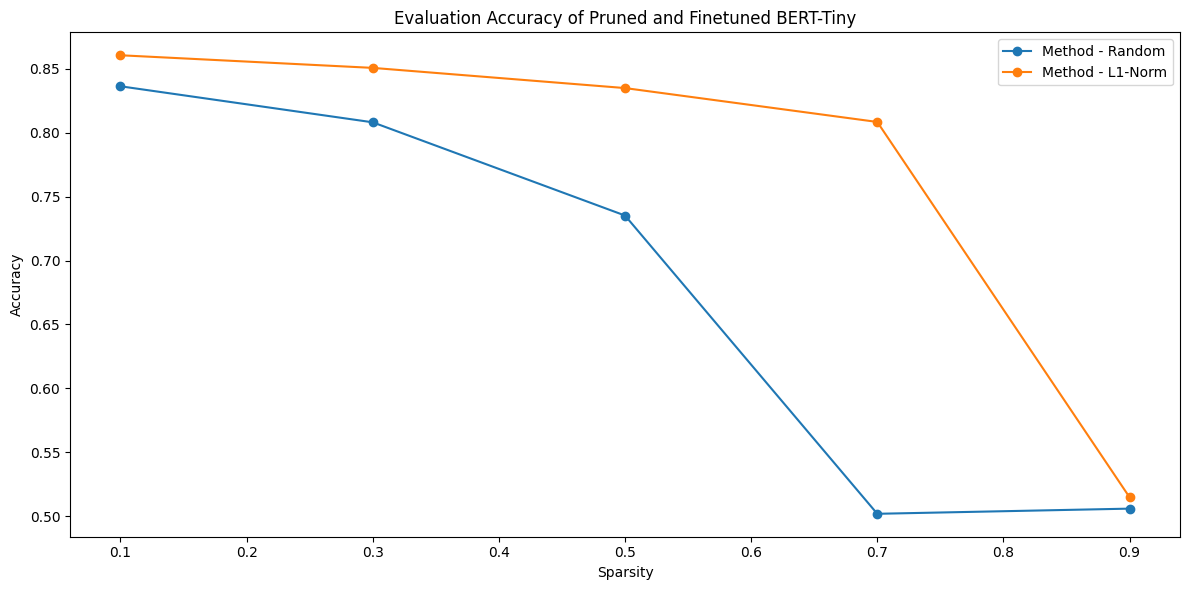

In [31]:
import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot method 1 results
# plt.subplot(1, 2, 1)
plt.plot(sparsities, method_1_results_finetune, label='Method - Random', marker='o')
# plt.xlabel('Sparsity')
# plt.ylabel('Accuracy')
# plt.title('Method 1 Results')
# plt.legend()

# # Plot method 2 results
# plt.subplot(1, 2, 2)
plt.plot(sparsities, method_2_results_finetune, label='Method - L1-Norm', marker='o')
plt.xlabel('Sparsity')
plt.ylabel('Accuracy')
plt.title('Evaluation Accuracy of Pruned and Finetuned BERT-Tiny')
plt.legend()
plt.tight_layout()
plt.savefig('tut4_sparsity_accuracy.png')
plt.show()